In [18]:
#colour: vel data via binning/gaussian
import jax
import jax.numpy as jnp
from jax import jit, random

import nifty8.re as jft
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import importlib
import time
current_dir = os.path.abspath('')
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

import util_working as util

jnp.set_printoptions(threshold=sys.maxsize)
importlib.reload(util)

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

In [19]:
''' Massenmodell '''
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])

rho_s = jft.LogNormalPrior(rhos, erhos, name="rho_s", shape=(15,))
sigma_s = jft.LogNormalPrior(sigmas, esigmas, name="sigma_s", shape=(15,))
rho_dm = jft.UniformPrior(0., 0.2, name="rho_dm", shape=(1,))

In [20]:
''' Domain '''
subsample = 'full_o1m4'
z2 = 200.
z1 = 1180.
z3 = 5000.

bins = np.loadtxt(f'data/bins_{subsample}.txt')

i2 = np.where(bins<=z2)[0][-1]
i1 = np.where(bins>=z1)[0][0]
z2 = bins[i2]
z1 = bins[i1]
n = int(z1)+1
n3 = int(z3-z1)+1

bins = bins[i2:i1+1]
n_bins = int(len(bins)-1)

''' Run '''
name = 'n:ff45it100 '
seed =  45
interval = 'neg'
unc = True

n_vi_iterations = 100
delta = 1e-4
n_samples = 20

poly = np.loadtxt(f'data/poly_{subsample}.txt')

In [21]:
''' Correlated Field '''
dims = (n, )
                             #old #new #newer(seeds)
cf_zm = dict(offset_mean=0., offset_std=(0.2, 0.2)) #0.3/0.3 #0.5/0.5 #0.3/0.3
cf_fl = dict(   fluctuations=(0.5, 0.3), #1/1 #1/1 #0.5/0.3
                loglogavgslope=(-4., 0.5), #-5/2 #-3/0.5 #-3/0.5
                flexibility=(1e-3, 1e-16),
                asperity=(1e-3, 1e-16),)

cfm = jft.CorrelatedFieldMaker("cf")
cfm.set_amplitude_total_offset(**cf_zm)
cfm.add_fluctuations(dims, distances=1.0, **cf_fl, prefix="ax1", non_parametric_kind="power")
correlated_field = cfm.finalize()

m_poly = jft.LogNormalPrior(poly[0], 0.2*poly[0], name="m_steig", shape=(1,)) #0.5/0.5 #0.5/0.5 #0.2/0.2
b_poly = jft.LogNormalPrior(poly[1], 0.2*poly[1], name="b_steig", shape=(1,))

In [22]:
''' Data '''
data = np.loadtxt(f'data/n_{subsample}.txt', dtype='int')
edata = np.loadtxt(f'data/n_std_{subsample}.txt', dtype='float')/np.loadtxt(f'data/n_mean_{subsample}.txt', dtype='float')
df_v2 = pd.read_csv(f'data/v2_bin_{subsample}.txt')
z_v2 = jnp.array(df_v2["z"].values)
vz_vars = jnp.array(df_v2["vz_vars"].values)
evz_vars = jnp.array(df_v2["evz_vars"].values)
vel_pos = np.where(z_v2>=0)
vel_neg = np.where(z_v2<0)

if interval == 'pos':
    data = data[i2:i1]
    edata = edata[i2:i1]
    z_v2 = z_v2[vel_pos]
    vz_vars = vz_vars[vel_pos]
    evz_vars = evz_vars[vel_pos]
elif interval == 'neg':
    data = np.flip(data)[i2:i1]
    edata = np.flip(edata)[i2:i1]
    z_v2 = abs(z_v2[vel_neg])
    vz_vars = vz_vars[vel_neg]
    evz_vars = evz_vars[vel_neg]
elif interval == 'both':
    data = np.flip(data)[i2:i1] + data[i2:i1]
    edata = np.sqrt(np.flip(edata)[i2:i1]**2 + edata[i2:i1]**2)
    z_v2 = abs(z_v2)
    vz_vars = vz_vars
    evz_vars = evz_vars

uncertainty = jft.LogNormalPrior(jnp.ones_like(edata), edata, name="uncertainty", shape=(len(edata),))

In [23]:
''' Forward Model '''
norm = jnp.sum(data)
string = f'z2:{z2} z1:{z1} data:{interval}'

class ForwardModel(jft.Model):
    def __init__(self):
        self.rho_s = rho_s
        self.sigma_s = sigma_s
        self.rho_dm = rho_dm
        self.correlated_field = correlated_field
        self.m_poly = m_poly
        self.b_poly = b_poly

        if unc == True:
            self.uncertainty = uncertainty
            
            super().__init__(init =  self.rho_s.init| self.sigma_s.init | self.rho_dm.init | self.correlated_field.init | self.m_poly.init | self.b_poly.init | self.uncertainty.init)
        elif unc == False:
            super().__init__(init =  self.rho_s.init| self.sigma_s.init | self.rho_dm.init | self.correlated_field.init | self.m_poly.init | self.b_poly.init)

    @jit
    def __call__(self, x):
        rs = self.rho_s(x)
        ss = self.sigma_s(x)
        rdm = self.rho_dm(x)
        m = self.m_poly(x)
        b = self.b_poly(x)

        if unc == True:
            ef = self.uncertainty(x)
        
        elif unc == False:
            ef = jnp.ones_like(data)

        rough_func = (b + m*jnp.linspace(0, z1, n))
            
        cf = rough_func * jnp.exp(self.correlated_field(x))

        def complicated_function(rho_s, sigma_s, rho_dm, cf):
            params = jnp.column_stack((rho_s, sigma_s))
            rho_dm = rho_dm[0]

            uz, zs = util.diffraxDopri5(rho_dm, params, z1, n)
            # sigma_sq = RegularGridInterpolator((zs, ), cf)
            # sig2 = sigma_sq(z_v2)
            uz_, zs_ = util.Solver(rho_dm, params, z1, z3, uz[-1], n3)
            vdfo_norm_calc, z, sig2 = util.vdfo_norm(z2, z1, zs, uz, n, poly, cf, z_v2)
            integral, z_borders = util.binning(vdfo_norm_calc, z, z2, z1, n, n_bins)
            surface_density_calc = util.surface_density(params, jnp.append(uz, uz_, axis=0), jnp.append(zs, zs_))
            m = uz_[-1,1]
            b = uz_[-1,0] - m*zs_[-1]
            correction = jnp.sum(params[:,0] * params[:,1]**2/m * jnp.exp(-(m*zs_[-1]+b)/params[:,1]**2))
            surface_density_calc = surface_density_calc + correction

            return integral * ef * norm/jnp.sum(integral), surface_density_calc, sig2, jnp.sum(params[:,0])
        dfo, sd, sig2, rho = complicated_function(rs, ss, rdm, cf)
        return jft.Vector({'dfo': dfo, 'sd': sd, 'sig2': sig2, 'rho': rho})

fwd = ForwardModel()
R_dfo = jft.Model(lambda x: x['dfo'], domain=fwd.target)
R_sd = jft.Model(lambda x: x['sd'], domain=fwd.target)
R_sig2 = jft.Model(lambda x: x['sig2'], domain=fwd.target)
R_rho = jft.Model(lambda x: x['rho'], domain=fwd.target)

lh_dfo = jft.Poissonian(data).amend(R_dfo)
lh_sd = jft.Gaussian(49.4, lambda x: 1/(4.6)**2 * x).amend(R_sd)
lh_sig2 = jft.Gaussian(vz_vars, lambda x: 1/evz_vars**2 * x).amend(R_sig2)
# lh_rho = jft.Gaussian(0.0914, lambda x: 1/0.014**2 * x).amend(R_rho)

lh = (lh_dfo + lh_sd + lh_sig2).amend(fwd)
#lh_dfo + lh_sd + lh_sig2 + lh_rho

C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\nifty8\re\model.py:160: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL Iteration 0000
SL: Iteration 0 ⛰:+6.8820e+03 Δ⛰:inf ➽:2.4410e-02
SL: Iteration 1 ⛰:+1.5922e+03 Δ⛰:5.2898e+03 ➽:2.4410e-02
SL: Iteration 2 ⛰:-5.7389e+02 Δ⛰:2.1661e+03 ➽:2.4410e-02
SL: Iteration 3 ⛰:-8.6065e+02 Δ⛰:2.8676e+02 ➽:2.4410e-02
SL: Iteration 4 ⛰:-9.8994e+02 Δ⛰:1.2928e+02 ➽:2.4410e-02
SL: Iteration 5 ⛰:-1.1620e+03 Δ⛰:1.7211e+02 ➽:2.4410e-02
SL: Iteration 6 ⛰:-1.1990e+03 Δ⛰:3.6923e+01 ➽:2.4410e-02
SL: Iteration 7 ⛰:-1.2148e+03 Δ⛰:1.5781e+01 ➽:2.4410e-02
SL: Iteration 8 ⛰:-1.2270e+03 Δ⛰:1.2220e+01 ➽:2.4410e-02
SL: Iteration 9 ⛰:-1.2283e+03 Δ⛰:1.2790e+00 ➽:2.4410e-02
SL: Iteration 10 ⛰:-1.2385e+03 Δ⛰:1.0269e+01 ➽:2.4410e-02
SL: Iteration 11 ⛰:-1.2453e+03 Δ⛰:6.8161e+00 ➽:2.4410e-02
SL: Iteration 12 ⛰:-1.2454e+03 Δ⛰:2.1950e-02 ➽:2.4410e-02
SL: Iteration 0 ⛰:+1.7847e+04 Δ⛰:inf ➽:2.4410e-02
SL: Iteration 1 ⛰:+4.1428e+03 Δ⛰:1.3705e+04 ➽:2.4410e-02
SL: Iteration 2 ⛰:-1.0020e+03 Δ⛰:5.1448e+03 ➽:2.4410e-02
SL: Iteration 3 ⛰:-1.0384e+03 Δ⛰:3.6426e+01 ➽:2.4410e-02
SL: Iteration 4

slope:  (Array([0.59770221], dtype=float64), Array([0.10053578], dtype=float64))
offset:  (Array([291.35837313], dtype=float64), Array([33.58260926], dtype=float64))
Time:  1598.0695569515228


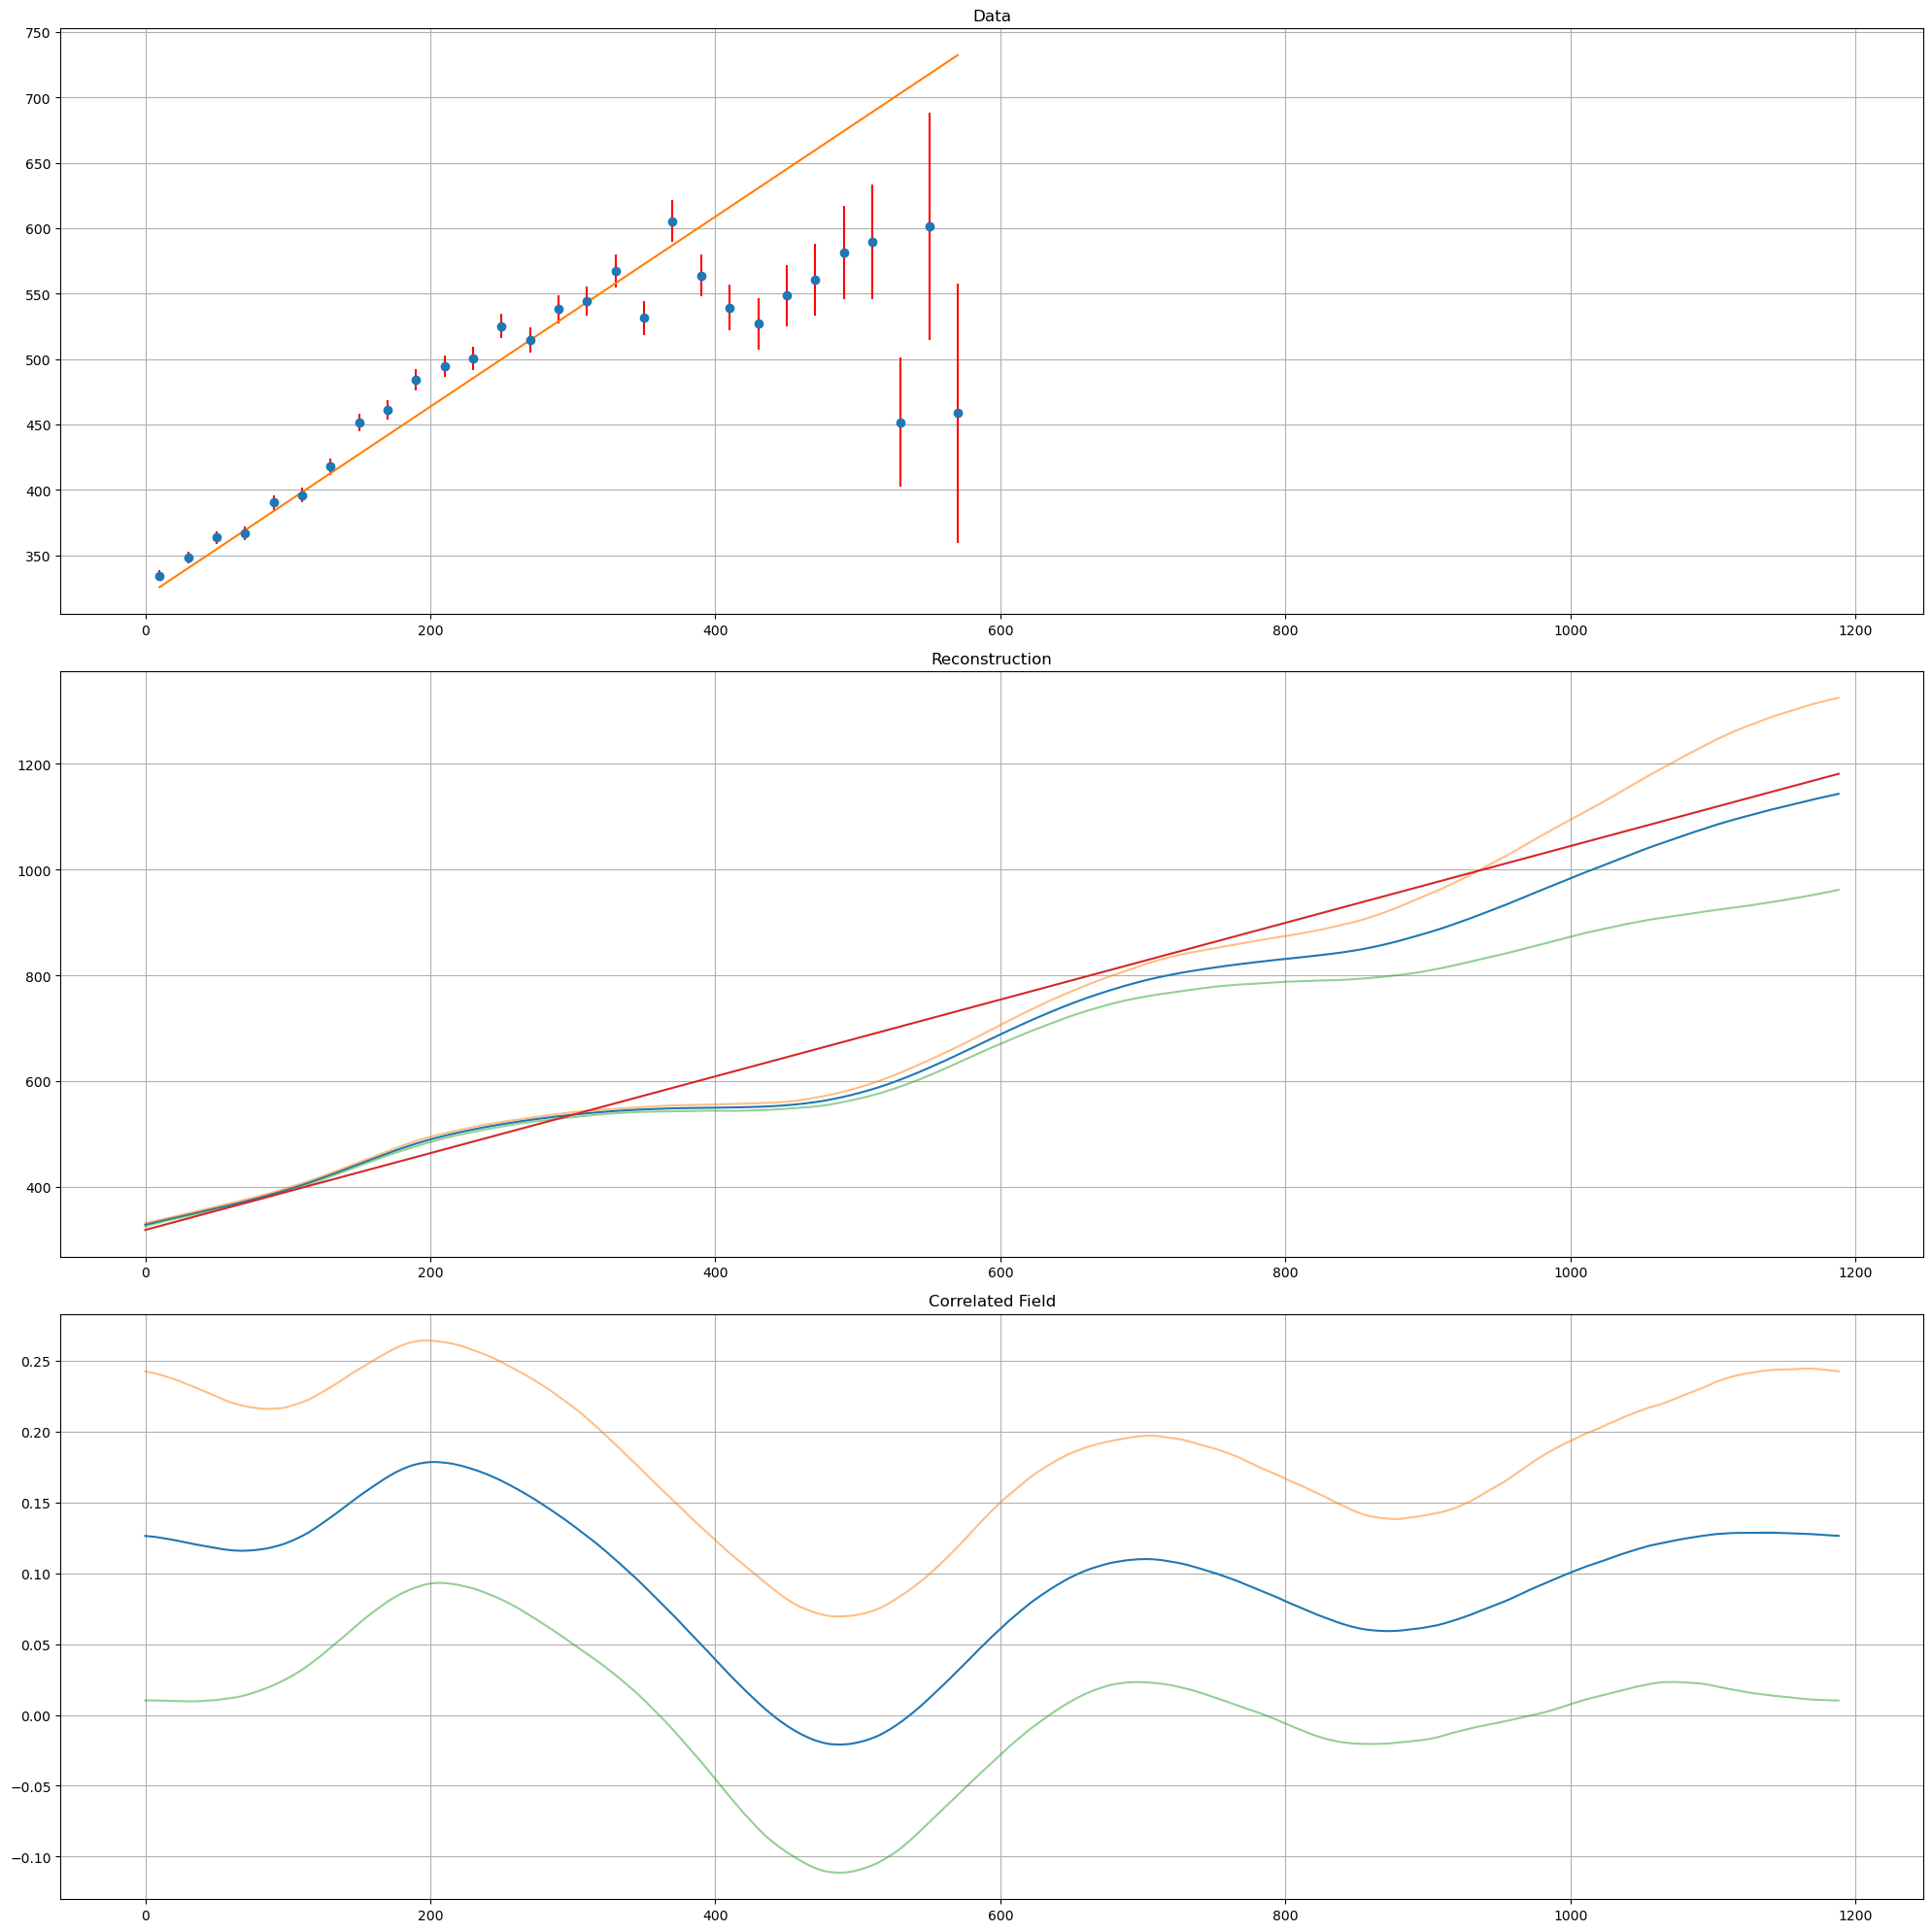

In [24]:
''' Optimization '''
key = random.PRNGKey(seed)
# key, subkey = random.split(key)
# pos_truth = jft.random_like(subkey, fwd.domain)
# dfo_truth = fwd(pos_truth)['dfo']
# sd_truth = fwd(pos_truth)['sd']
# sig2_truth = fwd(pos_truth)['sig2']
# print(len(dfo_truth), sd_truth, len(sig2_truth))
key, k_i, k_o = random.split(key, 3)

t0 = time.time()
samples, state = jft.optimize_kl(
    lh,
    jft.Vector(lh.init(k_i)),
    n_total_iterations=n_vi_iterations,
    n_samples=lambda i: n_samples // 2 if i < 2 else n_samples,
    # Source for the stochasticity for sampling
    key=k_o,
    # Arguments for the conjugate gradient method used to drawing samples from an implicit covariance matrix
    draw_linear_kwargs=dict(
        cg_name="SL",
        cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10.0, maxiter=100),
    ),
    # Arguements for the minimizer in the nonlinear updating of the samples
    nonlinearly_update_kwargs=dict(
        minimize_kwargs=dict(
            name="SN",
            xtol=delta,
            cg_kwargs=dict(name=None),
            maxiter=5,
        )
    ),
    # Arguments for the minimizer of the KL-divergence cost potential
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name="M", xtol=delta, cg_kwargs=dict(name=None), maxiter=35
        )
    ),
    sample_mode="nonlinear_resample",
    odir=None,#"./results_test",
    resume=False,
)

''' Results '''
results = {}

for k in range(15):
    exec(f'results["rhos{k+1}"] = tuple(rho_s(s)[{k}].tolist() for s in samples)')
    exec(f'results["sigmas{k+1}"] = tuple(sigma_s(s)[{k}].tolist() for s in samples)')
    exec(f'results["rho{k+1}"] = jft.mean_and_std(results["rhos{k+1}"])')
    exec(f'results["sigma{k+1}"] = jft.mean_and_std(results["sigmas{k+1}"])')
results["rhosdm"] = tuple(rho_dm(s).tolist()[0] for s in samples)
results["rhodm"] = jft.mean_and_std(results["rhosdm"])
results["surfds"] = tuple(fwd(s)['sd'].tolist() for s in samples)
results["surfd"] = jft.mean_and_std(results["surfds"])
print('slope: ', jft.mean_and_std(tuple(m_poly(s) for s in samples)))
print('offset: ', jft.mean_and_std(tuple(b_poly(s) for s in samples)))

Sigma_sq = jft.mean_and_std(tuple((b_poly(s) + m_poly(s)*jnp.linspace(0, z1, n)) * jnp.exp(correlated_field(s)) for s in samples))
corrfield = jft.mean_and_std(tuple(correlated_field(s) for s in samples))

dfo = jft.mean_and_std(tuple(fwd(s)["dfo"] for s in samples))
if unc == True:
    errorfreedom = jft.mean_and_std(tuple(uncertainty(s) for s in samples))
else:
    errorfreedom = (jnp.ones_like(data), jnp.zeros_like(data))

meanr = [results[f'rho{k+1}'][0] for k in range(15)] 
stdr = [results[f'rho{k+1}'][1] for k in range(15)] 

data_rho = {
    "Run": [name + f'rho_{k+1} ' + string for k in range(15)],
    "Inferred Value rho": meanr,
    "Standard Deviation rho": stdr,
    "Samples rho": [results[f'rhos{k+1}'] for k in range(15)]
}

meanrd = [results['rhodm'][0]]
stdrd = [results['rhodm'][1]]

data_rd = { 
    "Run": [name + f'rho_dm ' + string],
    "Inferred Value rho": meanrd,
    "Standard Deviation rho": stdrd,
    "Samples rho": [results['rhosdm']],
}

means = [results[f'sigma{k+1}'][0] for k in range(15)]
stds = [results[f'sigma{k+1}'][1] for k in range(15)]

data_sigma = {
    "Run": [name + f'sigma_{k+1} ' + string for k in range(15)],
    "Inferred Value sigma": means,
    "Standard Deviation sigma": stds,
    "Samples sigma": [results[f'sigmas{k+1}'] for k in range(15)]
}

meansd = [results['surfd'][0]]
stdsd = [results['surfd'][1]]

data_sd = {
    "Run": [name + 'surfdens ' + string],
    "Inferred Value sd": meansd,
    "Standard Deviation sd": stdsd,
    "Samples sd": [results['surfds']],
}

data_cf = {
    "Run": [name + 'corrfield ' + string],
    "Inferred Value cf": [corrfield[0]],
    "Standard Deviation cf": [corrfield[1]],
    "Inferred Value Sigma_sq": [Sigma_sq[0]],
    "Standard Deviation Sigma_sq": [Sigma_sq[1]],
}

data_dfo = {
    "Run": [name + 'dfo ' + string],
    "Inferred Value ef": [errorfreedom[0]],
    "Standard Deviation ef": [errorfreedom[1]],
    "Inferred Value dfo": [dfo[0]],
    "Standard Deviation dfo": [dfo[1]],
}

t1 = time.time()
print('Time: ', t1-t0)

dfr = pd.DataFrame(data_rho)
dfr.set_index('Run', inplace=True)
dfrd = pd.DataFrame(data_rd)
dfrd.set_index('Run', inplace=True)
dfs = pd.DataFrame(data_sigma)
dfs.set_index('Run', inplace=True)
dfsd = pd.DataFrame(data_sd)
dfsd.set_index('Run', inplace=True)
dfcf = pd.DataFrame(data_cf)
dfcf.set_index('Run', inplace=True)
dfdfo = pd.DataFrame(data_dfo)
dfdfo.set_index('Run', inplace=True)

''' Save Results '''
dfr.to_csv(f'results/rho_bin_{subsample}.csv', mode='a', header=False)
dfrd.to_csv(f'results/rd_bin_{subsample}.csv', mode='a', header=False)
dfs.to_csv(f'results/sigma_bin_{subsample}.csv', mode='a', header=False)
dfsd.to_csv(f'results/sd_bin_{subsample}.csv', mode='a', header=False)
dfcf.to_csv(f'results/cf_bin_{subsample}.csv', mode='a', header=False)
dfdfo.to_csv(f'results/dfo_bin_{subsample}.csv', mode='a', header=False)

''' Plot Results cf'''
to_plot = [("Data", (vz_vars,evz_vars), 'errorbar'), ("Reconstruction", Sigma_sq, 'plot'), ("Correlated Field", corrfield, 'plot2')]

fig, axs = plt.subplots(3, 1, figsize=(20, 20))
grid = jnp.linspace(0, z1, n)
for ax, v in zip(axs.flat, to_plot):
    title, field, tp = v
    ax.set_title(title)
    ax.grid()
    if tp == 'scatter':
        ax.scatter(z_v2, field, marker='.')
        ax.plot(z_v2, poly[0]*z_v2+poly[1])
        ax.sharex(axs[0])
    elif tp == 'errorbar':
        ax.errorbar(z_v2, field[0], yerr=field[1], fmt='o', ecolor='r')
        ax.plot(z_v2, poly[0]*z_v2+poly[1])
        ax.sharex(axs[0])
    elif tp == 'plot':
        ax.plot(grid, field[0])
        ax.plot(grid, field[0]+field[1], alpha=0.5)
        ax.plot(grid, field[0]-field[1], alpha=0.5)
        ax.plot(grid, poly[0]*grid+poly[1])
        ax.sharex(axs[0])
    elif tp == 'plot2':
        ax.plot(grid, field[0])
        ax.plot(grid, field[0]+field[1], alpha=0.5)
        ax.plot(grid, field[0]-field[1], alpha=0.5)
        ax.sharex(axs[0])
fig.tight_layout()
plt.show()

In [25]:
# a = []
# for i in range(3):
#     key, subkey = random.split(key)
#     b = jft.draw_residual(lh, samples.pos, subkey)
#     p = jft.unstack(b)
#     a += [p[0][0] + samples.pos]
#     a += [p[1][0] + samples.pos]


In [28]:

print(state)
print(samples)
key, subkey = random.split(key)
o = jft.OptimizeVI(lh, 1)
a, s = o.draw_samples(samples, key = state.key, n_samples = 200, sample_mode='nonlinear_resample', point_estimates=None)

OptimizeVIState(nit=99, key=Array([ 493266695, 2753679260], dtype=uint32), sample_state=OptimizeResults(x=None, success=Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True], dtype=bool), status=Array([0, 0, 0, 0, 0, 0, 5, 5, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0,
       5, 0, 0, 0, 0, 0, 0, 0, 5, 5, 0, 0, 0, 0, 0, 5, 0, 0],      dtype=int64, weak_type=True), fun=Array([ 0.28875936,  0.98379588,  2.00096991,  2.11062748,  7.62956125,
        6.31497226,  3.57196224,  5.73526597,  0.23197648,  0.56895924,
        2.61859218,  2.07134856,  0.92096962,  1.32608855, 11.47998448,
        7.1554281 ,  2.25557469,  3.42778208,  5.16603981,  2.18345072,
        9.04749599,  3.18211312, 10.53828402,  6.84946435, 10.60118151,
        7.

In [29]:
''' Results '''
results = {}

for k in range(15):
    exec(f'results["rhos{k+1}"] = tuple(rho_s(s)[{k}].tolist() for s in a)')
    exec(f'results["sigmas{k+1}"] = tuple(sigma_s(s)[{k}].tolist() for s in a)')
    exec(f'results["rho{k+1}"] = jft.mean_and_std(results["rhos{k+1}"])')
    exec(f'results["sigma{k+1}"] = jft.mean_and_std(results["sigmas{k+1}"])')
results["rhosdm"] = tuple(rho_dm(s).tolist()[0] for s in a)
results["rhodm"] = jft.mean_and_std(results["rhosdm"])
results["surfds"] = tuple(fwd(s)['sd'].tolist() for s in a)
results["surfd"] = jft.mean_and_std(results["surfds"])
print('slope: ', jft.mean_and_std(tuple(m_poly(s) for s in a)))
print('offset: ', jft.mean_and_std(tuple(b_poly(s) for s in a)))

Sigma_sq = jft.mean_and_std(tuple((b_poly(s) + m_poly(s)*jnp.linspace(0, z1, n)) * jnp.exp(correlated_field(s)) for s in a))
corrfield = jft.mean_and_std(tuple(correlated_field(s) for s in a))

dfo = jft.mean_and_std(tuple(fwd(s)["dfo"] for s in a))
if unc == True:
    errorfreedom = jft.mean_and_std(tuple(uncertainty(s) for s in a))
else:
    errorfreedom = (jnp.ones_like(data), jnp.zeros_like(data))

meanr = [results[f'rho{k+1}'][0] for k in range(15)] 
stdr = [results[f'rho{k+1}'][1] for k in range(15)] 

data_rho = {
    "Run": [name + f'rho_{k+1} ' + string for k in range(15)],
    "Inferred Value rho": meanr,
    "Standard Deviation rho": stdr,
    "Samples rho": [results[f'rhos{k+1}'] for k in range(15)]
}

meanrd = [results['rhodm'][0]]
stdrd = [results['rhodm'][1]]

data_rd = { 
    "Run": [name + f'rho_dm ' + string],
    "Inferred Value rho": meanrd,
    "Standard Deviation rho": stdrd,
    "Samples rho": [results['rhosdm']],
}

means = [results[f'sigma{k+1}'][0] for k in range(15)]
stds = [results[f'sigma{k+1}'][1] for k in range(15)]

data_sigma = {
    "Run": [name + f'sigma_{k+1} ' + string for k in range(15)],
    "Inferred Value sigma": means,
    "Standard Deviation sigma": stds,
    "Samples sigma": [results[f'sigmas{k+1}'] for k in range(15)]
}

meansd = [results['surfd'][0]]
stdsd = [results['surfd'][1]]

data_sd = {
    "Run": [name + 'surfdens ' + string],
    "Inferred Value sd": meansd,
    "Standard Deviation sd": stdsd,
    "Samples sd": [results['surfds']],
}

data_cf = {
    "Run": [name + 'corrfield ' + string],
    "Inferred Value cf": [corrfield[0]],
    "Standard Deviation cf": [corrfield[1]],
    "Inferred Value Sigma_sq": [Sigma_sq[0]],
    "Standard Deviation Sigma_sq": [Sigma_sq[1]],
}

data_dfo = {
    "Run": [name + 'dfo ' + string],
    "Inferred Value ef": [errorfreedom[0]],
    "Standard Deviation ef": [errorfreedom[1]],
    "Inferred Value dfo": [dfo[0]],
    "Standard Deviation dfo": [dfo[1]],
}


dfr = pd.DataFrame(data_rho)
dfr.set_index('Run', inplace=True)
dfrd = pd.DataFrame(data_rd)
dfrd.set_index('Run', inplace=True)
dfs = pd.DataFrame(data_sigma)
dfs.set_index('Run', inplace=True)
dfsd = pd.DataFrame(data_sd)
dfsd.set_index('Run', inplace=True)
dfcf = pd.DataFrame(data_cf)
dfcf.set_index('Run', inplace=True)
dfdfo = pd.DataFrame(data_dfo)
dfdfo.set_index('Run', inplace=True)

''' Save Results '''
dfr.to_csv(f'results/rho_bin_{subsample}re.csv', mode='a', header=False)
dfrd.to_csv(f'results/rd_bin_{subsample}re.csv', mode='a', header=False)
dfs.to_csv(f'results/sigma_bin_{subsample}re.csv', mode='a', header=False)
dfsd.to_csv(f'results/sd_bin_{subsample}re.csv', mode='a', header=False)
dfcf.to_csv(f'results/cf_bin_{subsample}re.csv', mode='a', header=False)
dfdfo.to_csv(f'results/dfo_bin_{subsample}re.csv', mode='a', header=False)

slope:  (Array([0.59844539], dtype=float64), Array([0.08823487], dtype=float64))
offset:  (Array([291.98340673], dtype=float64), Array([30.97819407], dtype=float64))
